In [ ]:
#---------------------------------------------------------------import statements required-----------------------------------------------------------------------------------------------------

import pandas as pd #used for data processing and file reading
import  matplotlib as plt #used for visualization 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np #used for linear algebra
import sklearn as sk #used for linear regression model
import statsmodels.api as sm #used for regression diagnostics
from xgboost import XGBRegressor as xgb #used for gradient boosted regression method
import seaborn as sb # used for visualization
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#pip install pandas matplotlib numpy scikit-learn statsmodels xgboost seaborn

# -------------------------------------------------------------------------- Config -----------------------------------------------------------------------------------------------------------
REQUIRED_COLS = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]

VALID_SEX = {"male": "male", "m": "male", "female": "female", "f": "female"}
VALID_SMOKER = {
    "yes": "yes", "y": "yes", "true": "yes", "1": "yes",
    "no": "no", "n": "no", "false": "no", "0": "no"
}
VALID_REGION = {
    "southwest":"southwest","southeast":"southeast",
    "northwest":"northwest","northeast":"northeast",
    "sw":"southwest","se":"southeast","nw":"northwest","ne":"northeast"
}

Mean Absolute Error: 2594.13
R2 Score: 0.866


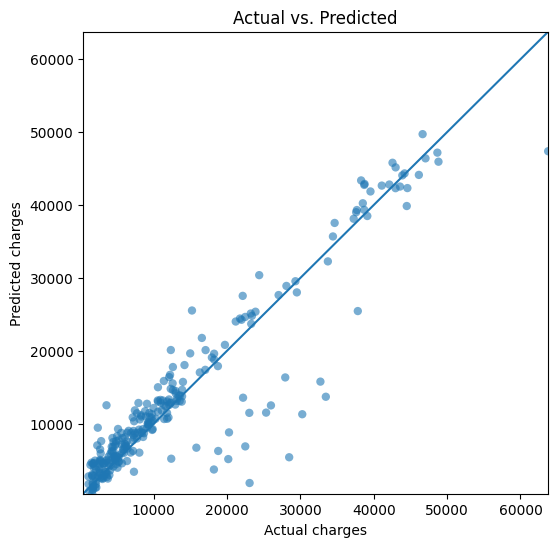

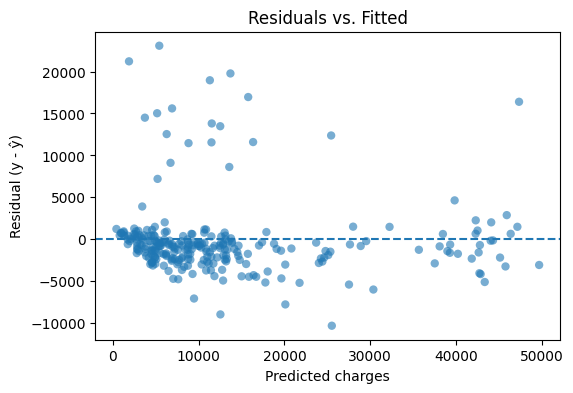

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
import pandas as pd 
import  matplotlib as plt 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import sklearn as sk 
import statsmodels.api as sm 
from xgboost import XGBRegressor as xgb 
import seaborn as sb
#----------------------------------------------------------------------XGB Method--------------------------------------------------------------------------------------------------------------

data = pd.read_csv("../csv/insurance.csv")

x = data.drop("charges",axis=1)
y = data["charges"]

x_train,x_test, y_train, y_test= sk.model_selection.train_test_split(x,y,test_size=0.2, random_state=42)

cat =["sex","smoker","region"]
num = ["age","bmi","children"]

preprocessor = sk.compose.ColumnTransformer([("cat", sk.preprocessing.OneHotEncoder(handle_unknown="ignore"),cat)],remainder="passthrough")

model = xgb(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)

pipeline = sk.pipeline.Pipeline(steps=[("preprocessor",preprocessor),("model",model)])

pipeline.fit(x_train,y_train)

y_pred = pipeline.predict(x_test)

mae=sk.metrics.mean_absolute_error(y_test,y_pred)
r2=sk.metrics.r2_score(y_test,y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")



#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#----------------------------------------------------------------------------visualizations----------------------------------------------------------------------------------------------------


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="none")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Actual vs. Predicted")
plt.show()


residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor="none")
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted charges")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs. Fitted")
plt.show()


sk.set_config(display="diagram")
pipeline

Cleaned dataset shape: (1338, 7)


,dtype,n_missing,n_unique,min,max
age,int64,0,47,18.00000,64.000000
sex,object,0,2,NaN,NaN
bmi,float64,0,527,17.89515,46.407900
children,int64,0,6,0.00000,5.000000
smoker,object,0,2,NaN,NaN
region,object,0,4,NaN,NaN
charges,float64,0,1311,1252.97273,48537.480726


Category levels: {'sex': ['female', 'male'], 'smoker': ['no', 'yes'], 'region': ['northeast', 'northwest', 'southeast', 'southwest']}

=== Model Evaluation ===
MAE: 2,152.808
RMSE: 4,456.631
R2: 0.868
Cost function: Mean Squared Error (MSE) — trained on log1p(charges)


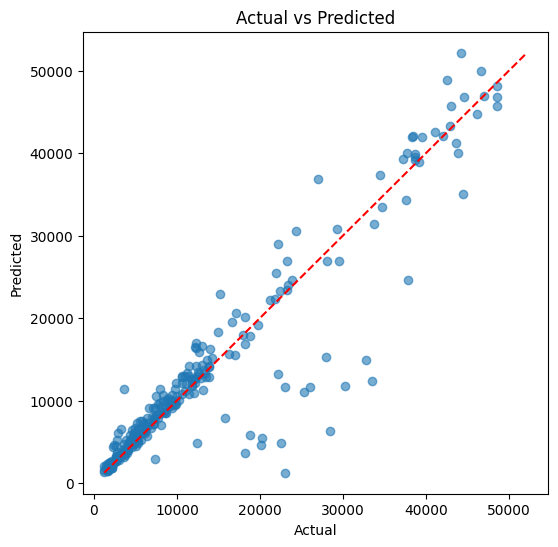

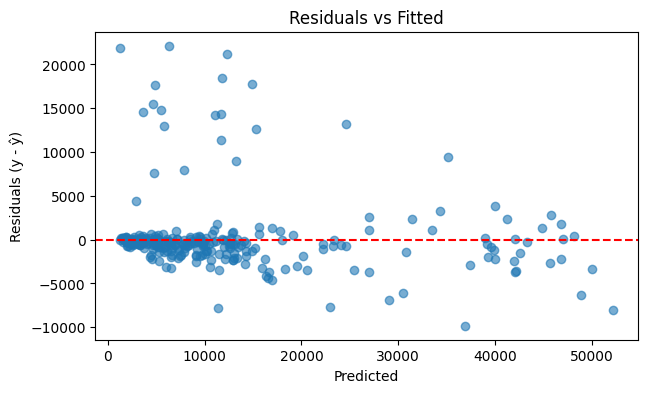

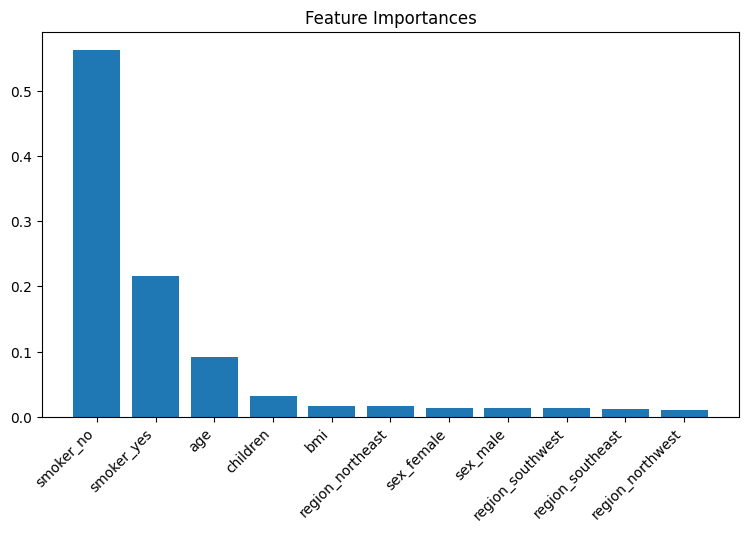


Predicted annual charge: $6,108.86
Cost function used: Mean Squared Error (MSE) — trained on log1p(charges)


In [2]:
# attempted master script 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from xgboost import XGBRegressor as xgb
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display

# === CONFIG ===
REQUIRED_COLS = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
VALID_SEX = {"male": "male", "m": "male", "female": "female", "f": "female"}
VALID_SMOKER = {"yes": "yes","y":"yes","true":"yes","1":"yes","no":"no","n":"no","false":"no","0":"no"}
VALID_REGION = {"southwest":"southwest","southeast":"southeast","northwest":"northwest","northeast":"northeast",
                "sw":"southwest","se":"southeast","nw":"northwest","ne":"northeast"}

# === UTILITIES ===
def _iqr_winsorize(series, low_q=0.01, high_q=0.99):
    lo, hi = series.quantile([low_q, high_q])
    return series.clip(lo, hi)

def _coerce_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _strip_lower(s): return s.astype(str).str.strip().str.lower()
def _normalize_map(s, mapping, default=np.nan): return _strip_lower(s).map(mapping).fillna(default)

def validate_schema(df):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

def basic_quality_report(df):
    num = df.select_dtypes(include=np.number)
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "n_unique": df.nunique()
    })
    rep["min"] = pd.Series({c: num[c].min() for c in num.columns})
    rep["max"] = pd.Series({c: num[c].max() for c in num.columns})
    return rep

# === DATA CLEANING (duplicates kept) ===
def clean_insurance(df, verbose=True):
    df = df.copy()
    validate_schema(df)

    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].astype(str).str.strip()

    df["sex"]    = _normalize_map(df["sex"], VALID_SEX)
    df["smoker"] = _normalize_map(df["smoker"], VALID_SMOKER)
    df["region"] = _normalize_map(df["region"], VALID_REGION)
    df = _coerce_numeric(df, ["age", "bmi", "children", "charges"])

    df = df.dropna(subset=REQUIRED_COLS)
    df = df[(df["age"] >= 0) & (df["bmi"] > 0) & (df["children"] >= 0) & (df["charges"] >= 0)]
    df = df[df["age"].between(0, 100)]
    df = df[df["bmi"].between(10, 80)]
    df["children"] = df["children"].round().astype(int)

    # keep duplicates (survey-based)
    for c in ["age", "bmi", "charges"]:
        df[c] = _iqr_winsorize(df[c])

    if verbose:
        print("Cleaned dataset shape:", df.shape)
        display(basic_quality_report(df))
        print("Category levels:",
              {c: sorted(df[c].dropna().unique().tolist()) for c in ["sex", "smoker", "region"]})
    return df

# === PIPELINE / MODEL ===
def make_splits(df, target="charges", test_size=0.2, seed=42):
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=seed)

def make_preprocessor(categorical, numeric):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), categorical)], remainder="passthrough")

def make_model(**kwargs):
    params = dict(n_estimators=600, learning_rate=0.05, max_depth=4,
                  subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42)
    params.update(kwargs)
    return xgb(**params)

def transform_target(y, use_log): return np.log1p(y) if use_log else y
def inverse_target(y, used_log): return np.expm1(y) if used_log else y

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# === VISUALS ===
def plot_actual_vs_pred(y_true, y_pred):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title("Actual vs Predicted"); plt.show()

def plot_residuals(y_true, y_pred):
    plt.figure(figsize=(7,4))
    plt.scatter(y_pred, y_true - y_pred, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted"); plt.ylabel("Residuals (y - ŷ)")
    plt.title("Residuals vs Fitted"); plt.show()

def plot_feature_importance(pipeline, X):
    pre = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]
    ohe = pre.named_transformers_["cat"]
    cat_cols = pre.transformers_[0][2]
    cat_names = ohe.get_feature_names_out(cat_cols)
    num_cols = [c for c in X.columns if c not in cat_cols]
    feature_names = np.r_[cat_names, num_cols]
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(9,5))
    plt.bar(range(len(importances)), importances[order])
    plt.xticks(range(len(importances)), feature_names[order], rotation=45, ha="right")
    plt.title("Feature Importances"); plt.show()

# === COST FUNCTION INFO ===
def _objective_human_readable(obj, used_log):
    mapping = {"reg:squarederror": "Mean Squared Error (MSE)",
               "reg:absoluteerror": "Mean Absolute Error (L1)",
               "reg:pseudohubererror": "Pseudo-Huber Loss (robust)",
               "reg:squaredlogerror": "Squared Log Error"}
    base = mapping.get(obj, obj)
    return f"{base} — trained on {'log1p(charges)' if used_log else 'original $ scale'}"

def get_pipeline_objective(pipeline, used_log):
    model = pipeline.named_steps["model"]
    obj = model.get_xgb_params().get("objective", "reg:squarederror")
    return _objective_human_readable(obj, used_log)

# === USER INPUT ===
def parse_user_row(age, sex, bmi, children, smoker, region):
    age = int(age); bmi = float(bmi); children = int(children)
    sex = VALID_SEX.get(str(sex).lower(), sex)
    smoker = VALID_SMOKER.get(str(smoker).lower(), smoker)
    region = VALID_REGION.get(str(region).lower(), region)
    return {"age": age, "sex": sex, "bmi": bmi, "children": children, "smoker": smoker, "region": region}

def predict_from_inputs(pipeline, use_log_target, **kwargs):
    X_new = pd.DataFrame([parse_user_row(**kwargs)])
    yhat_t = pipeline.predict(X_new)
    yhat = inverse_target(yhat_t, use_log_target)
    return float(yhat[0]), get_pipeline_objective(pipeline, use_log_target)

# === TRAIN, EVALUATE, PREDICT ===
df_raw = pd.read_csv("../csv/insurance.csv")
df_clean = clean_insurance(df_raw, verbose=True)

USE_LOG_TARGET = True
X_train, X_test, y_train, y_test = make_splits(df_clean)
pre = make_preprocessor(["sex", "smoker", "region"], ["age", "bmi", "children"])
model = make_model()
pipe = Pipeline([("preprocessor", pre), ("model", model)])
pipe.fit(X_train, transform_target(y_train, USE_LOG_TARGET))
y_pred = inverse_target(pipe.predict(X_test), USE_LOG_TARGET)

metrics = evaluate_regression(y_test, y_pred)
print("\n=== Model Evaluation ===")
for k, v in metrics.items(): print(f"{k}: {v:,.3f}")
print("Cost function:", get_pipeline_objective(pipe, USE_LOG_TARGET))

# === VISUALS ===
plot_actual_vs_pred(y_test, y_pred)
plot_residuals(y_test, y_pred)
plot_feature_importance(pipe, X_train)

# === USER PREDICTION EXAMPLE ===
pred, cost_fn = predict_from_inputs(pipe, USE_LOG_TARGET,
    age=38, sex="male", bmi=28.4, children=2, smoker="no", region="southeast")
print(f"\nPredicted annual charge: ${pred:,.2f}")
print("Cost function used:", cost_fn)



Cleaned dataset shape: (1338, 7)


,dtype,n_missing,n_unique,min,max
age,int64,0,47,18.00000,64.000000
sex,object,0,2,NaN,NaN
bmi,float64,0,527,17.89515,46.407900
children,int64,0,6,0.00000,5.000000
smoker,object,0,2,NaN,NaN
region,object,0,4,NaN,NaN
charges,float64,0,1311,1252.97273,48537.480726


Category levels: {'sex': ['female', 'male'], 'smoker': ['no', 'yes'], 'region': ['northeast', 'northwest', 'southeast', 'southwest']}

=== Model Evaluation ===
MAE: 2,152.808
RMSE: 4,456.631
R2: 0.868
Cost function: Mean Squared Error (MSE) — trained on log1p(charges)


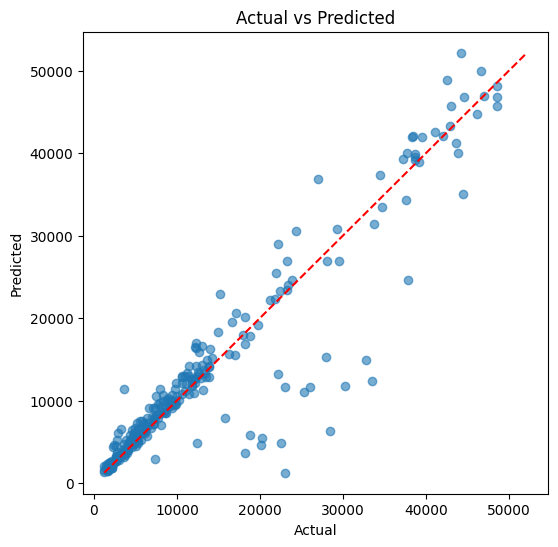

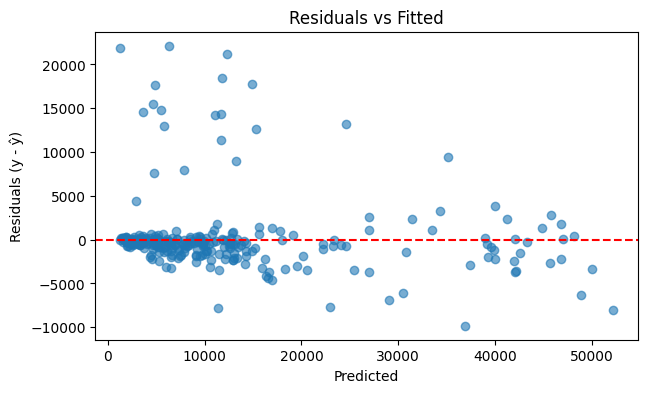

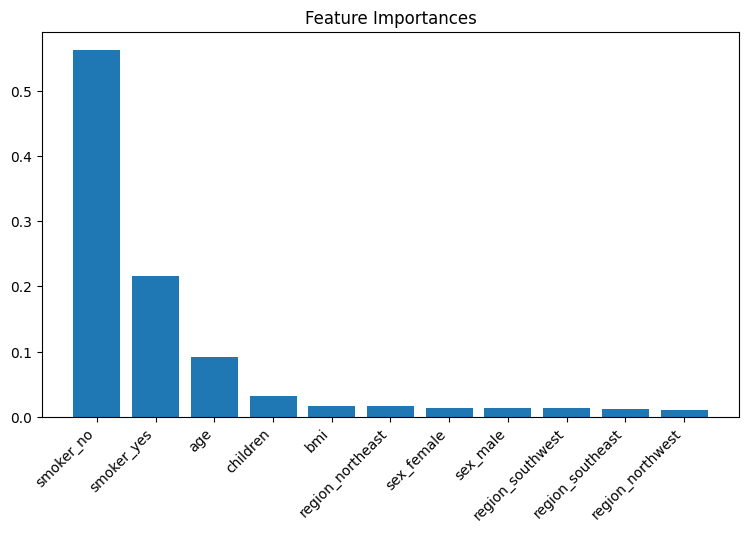

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from xgboost import XGBRegressor as xgb
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display, HTML
import ipywidgets as W

# === CONFIG ===
REQUIRED_COLS = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]
VALID_SEX = {"male": "male", "m": "male", "female": "female", "f": "female"}
VALID_SMOKER = {"yes": "yes","y":"yes","true":"yes","1":"yes",
                "no":"no","n":"no","false":"no","0":"no"}
VALID_REGION = {"southwest":"southwest","southeast":"southeast",
                "northwest":"northwest","northeast":"northeast",
                "sw":"southwest","se":"southeast","nw":"northwest","ne":"northeast"}

# toggle: train on log1p(charges) for stability on skewed costs
USE_LOG_TARGET = True

# === UTILITIES / CLEANING (duplicates kept) ===
def _iqr_winsorize(series, low_q=0.01, high_q=0.99):
    lo, hi = series.quantile([low_q, high_q])
    return series.clip(lo, hi)

def _coerce_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _strip_lower(s): return s.astype(str).str.strip().str.lower()
def _normalize_map(s, mapping, default=np.nan): return _strip_lower(s).map(mapping).fillna(default)

def validate_schema(df):
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

def basic_quality_report(df):
    num = df.select_dtypes(include=np.number)
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "n_unique": df.nunique()
    })
    rep["min"] = pd.Series({c: num[c].min() for c in num.columns})
    rep["max"] = pd.Series({c: num[c].max() for c in num.columns})
    return rep

def clean_insurance(df, verbose=True):
    df = df.copy()
    validate_schema(df)

    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].astype(str).str.strip()

    df["sex"]    = _normalize_map(df["sex"], VALID_SEX)
    df["smoker"] = _normalize_map(df["smoker"], VALID_SMOKER)
    df["region"] = _normalize_map(df["region"], VALID_REGION)
    df = _coerce_numeric(df, ["age", "bmi", "children", "charges"])

    df = df.dropna(subset=REQUIRED_COLS)
    df = df[(df["age"] >= 0) & (df["bmi"] > 0) & (df["children"] >= 0) & (df["charges"] >= 0)]
    df = df[df["age"].between(0, 100)]
    df = df[df["bmi"].between(10, 80)]
    df["children"] = df["children"].round().astype(int)

    # keep duplicates (survey data)
    for c in ["age", "bmi", "charges"]:
        df[c] = _iqr_winsorize(df[c])

    if verbose:
        print("Cleaned dataset shape:", df.shape)
        display(basic_quality_report(df))
        print("Category levels:",
              {c: sorted(df[c].dropna().unique().tolist()) for c in ["sex", "smoker", "region"]})
    return df

# === PIPELINE / MODEL ===
def make_splits(df, target="charges", test_size=0.2, seed=42):
    X = df.drop(columns=[target])
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=seed)

def make_preprocessor(categorical, numeric):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
                             remainder="passthrough")

def make_model(**kwargs):
    params = dict(n_estimators=600, learning_rate=0.05, max_depth=4,
                  subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42)
    params.update(kwargs)
    return xgb(**params)

def transform_target(y, use_log): return np.log1p(y) if use_log else y
def inverse_target(y, used_log): return np.expm1(y) if used_log else y

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# === COST FUNCTION INFO ===
def _objective_human_readable(obj, used_log):
    mapping = {"reg:squarederror": "Mean Squared Error (MSE)",
               "reg:absoluteerror": "Mean Absolute Error (L1)",
               "reg:pseudohubererror": "Pseudo-Huber Loss (robust)",
               "reg:squaredlogerror": "Squared Log Error",
               "count:poisson": "Poisson regression",
               "reg:gamma": "Gamma (right-skewed positive targets)"}
    base = mapping.get(obj, obj)
    return f"{base} — trained on {'log1p(charges)' if used_log else 'original $ scale'}"

def get_pipeline_objective(pipeline, used_log):
    model = pipeline.named_steps["model"]
    obj = model.get_xgb_params().get("objective", "reg:squarederror")
    return _objective_human_readable(obj, used_log)

# === VISUALS ===
def plot_actual_vs_pred(y_true, y_pred):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title("Actual vs Predicted"); plt.show()

def plot_residuals(y_true, y_pred):
    plt.figure(figsize=(7,4))
    plt.scatter(y_pred, y_true - y_pred, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted"); plt.ylabel("Residuals (y - ŷ)")
    plt.title("Residuals vs Fitted"); plt.show()

def plot_feature_importance(pipeline, X):
    pre = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]
    ohe = pre.named_transformers_["cat"]
    cat_cols = pre.transformers_[0][2]
    cat_names = ohe.get_feature_names_out(cat_cols)
    num_cols = [c for c in X.columns if c not in cat_cols]
    feature_names = np.r_[cat_names, num_cols]
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(9,5))
    plt.bar(range(len(importances)), importances[order])
    plt.xticks(range(len(importances)), feature_names[order], rotation=45, ha="right")
    plt.title("Feature Importances"); plt.show()

# === LOAD, CLEAN, TRAIN, EVAL ===
df_raw = pd.read_csv("../csv/insurance.csv")
df_clean = clean_insurance(df_raw, verbose=True)

X_train, X_test, y_train, y_test = make_splits(df_clean)
pre = make_preprocessor(["sex", "smoker", "region"], ["age", "bmi", "children"])
model = make_model()  # e.g., override: make_model(objective="reg:absoluteerror")
pipe = Pipeline([("preprocessor", pre), ("model", model)])

y_train_t = transform_target(y_train, USE_LOG_TARGET)
pipe.fit(X_train, y_train_t)

y_pred = inverse_target(pipe.predict(X_test), USE_LOG_TARGET)
metrics = evaluate_regression(y_test, y_pred)
print("\n=== Model Evaluation ===")
for k, v in metrics.items(): print(f"{k}: {v:,.3f}")
print("Cost function:", get_pipeline_objective(pipe, USE_LOG_TARGET))

plot_actual_vs_pred(y_test, y_pred)
plot_residuals(y_test, y_pred)
plot_feature_importance(pipe, X_train)

# === IPYWIDGETS: INTERACTIVE PREDICTOR ===
def predict_from_inputs(pipeline, use_log_target, *, age, sex, bmi, children, smoker, region):
    # canonicalize categorical input from dropdowns
    row = {"age": int(age),
           "sex": VALID_SEX.get(str(sex).lower(), sex),
           "bmi": float(bmi),
           "children": int(children),
           "smoker": VALID_SMOKER.get(str(smoker).lower(), smoker),
           "region": VALID_REGION.get(str(region).lower(), region)}
    X_new = pd.DataFrame([row])
    yhat = inverse_target(pipeline.predict(X_new), use_log_target)
    return float(yhat[0])

# widgets
w_age      = W.IntSlider(description="Age", value=40, min=0, max=100, step=1, continuous_update=False)
w_bmi      = W.FloatSlider(description="BMI", value=27.5, min=10.0, max=80.0, step=0.1, readout_format=".1f", continuous_update=False)
w_children = W.IntSlider(description="Children", value=2, min=0, max=10, step=1, continuous_update=False)
w_sex      = W.Dropdown(description="Sex", options=["male","female"], value="male")
w_smoker   = W.Dropdown(description="Smoker", options=["no","yes"], value="no")
w_region   = W.Dropdown(description="Region", options=["northeast","northwest","southeast","southwest"], value="southeast")
w_button   = W.Button(description="Predict", button_style="primary")
w_out      = W.Output()

def on_predict_click(_):
    with w_out:
        w_out.clear_output()
        pred = predict_from_inputs(
            pipe, USE_LOG_TARGET,
            age=w_age.value, sex=w_sex.value, bmi=w_bmi.value,
            children=w_children.value, smoker=w_smoker.value, region=w_region.value
        )
        cost_fn = get_pipeline_objective(pipe, USE_LOG_TARGET)
        display(HTML(f"<h4>Estimated annual charge: ${pred:,.2f}</h4>"))
        display(HTML(f"<div>Cost function used: {cost_fn}</div>"))

w_button.on_click(on_predict_click)

ui = W.VBox([
    W.HTML("<h3>Interactive Insurance Cost Predictor</h3>"),
    W.HBox([w_age, w_bmi, w_children]),
    W.HBox([w_sex, w_smoker, w_region]),
    w_button,
    w_out
])

display(ui)
